In [198]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from matplotlib.ticker import MultipleLocator
import seaborn as sns

In [199]:
df = pd.read_csv('Bimetal_Dataset_200Runs.csv')
X = df[['Length_mm', 'TPU_Thick_mm', 'PLA_Thick_mm']]
y = df[['Deflection_mm']]

df.rename(columns={"Length_mm": "len", "TPU_Thick_mm": "TPU", "PLA_Thick_mm" : "PLA", "Deflection_mm": "U"})


,Run_ID,len,TPU,PLA,PLA_Ratio,Temp_Change_C,U
0,1,236.50,1.38,0.89,0.39,60.0,-111.3726
1,2,152.07,0.64,1.42,0.69,60.0,-52.3240
2,3,159.40,1.14,0.84,0.42,60.0,-60.1944
3,4,269.34,1.18,0.96,0.45,60.0,-147.3424
4,5,246.53,1.48,0.46,0.24,60.0,-135.7171
...,...,...,...,...,...,...,...
195,196,216.90,0.97,1.43,0.60,60.0,-90.2566
196,197,129.51,1.47,1.23,0.46,60.0,-30.0921
197,198,117.13,0.54,1.27,0.70,60.0,-35.3876
198,199,126.95,0.74,0.82,0.53,60.0,-48.0623


In [200]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape:  {X_test.shape}")

Training Features Shape: (150, 3)
Testing Features Shape:  (50, 3)


In [201]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [202]:
poly = PolynomialFeatures(degree=1, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)

X_test_poly = poly.fit_transform(X_test_scaled)

print(f"Original Feature Count: {X_train_scaled.shape[1]}")
print(f"Polynomial Feature Count: {X_train_poly.shape[1]}")

Original Feature Count: 3
Polynomial Feature Count: 3


In [203]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

intercept_val = np.ravel(model.intercept_)[0]
print(f"\nModel Intercept (Baseline Deflection): {intercept_val:.4f}")


Model Intercept (Baseline Deflection): -102.8774


In [204]:
intercept_val = np.ravel(model.intercept_)[0]
print(f"\nModel Intercept (Baseline Deflection): {intercept_val:.4f}")

y_train_pred = model.predict(X_train_poly)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)

y_test_pred = model.predict(X_test_poly)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\n--- Single Split Performance ---")
print(f"Training RMSE: {train_rmse:.4f} mm")
print(f"Testing RMSE:  {test_rmse:.4f} mm")
print(f"Testing R-squared: {test_r2:.4f}")

pipeline = Pipeline([
    ('scaler', StandardScaler()),
('poly', PolynomialFeatures(degree=1, include_bias=False)),
    ('model', LinearRegression())
])

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline, X, y,
    cv=kfold,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

# Extract and convert the negative MSE to RMSE
train_rmse_scores = np.sqrt(-cv_results['train_score'])
test_rmse_scores = np.sqrt(-cv_results['test_score'])

print(f"\n--- 10-Fold Cross-Validation Performance")
print(f"Train RMSE across 10 folds: {np.round(train_rmse_scores, 4)}")
print(f"Test RMSE across 10 folds:  {np.round(test_rmse_scores, 4)}\n")

print(f"Average CV Training RMSE: {train_rmse_scores.mean():.4f} mm")
print(f"Average CV Testing RMSE:  {test_rmse_scores.mean():.4f} mm")


Model Intercept (Baseline Deflection): -102.8774

--- Single Split Performance ---
Training RMSE: 14.3076 mm
Testing RMSE:  10.0400 mm
Testing R-squared: 0.9618

--- 10-Fold Cross-Validation Performance
Train RMSE across 10 folds: [13.4399 13.4636 13.3721  7.3226 13.4959 13.4412 13.497  13.355  13.542
 13.2277]
Test RMSE across 10 folds:  [ 7.7519  7.1546  8.6516 35.3219  6.6474  7.5033  6.547   8.848   5.7328
 10.5902]

Average CV Training RMSE: 12.8157 mm
Average CV Testing RMSE:  10.4749 mm


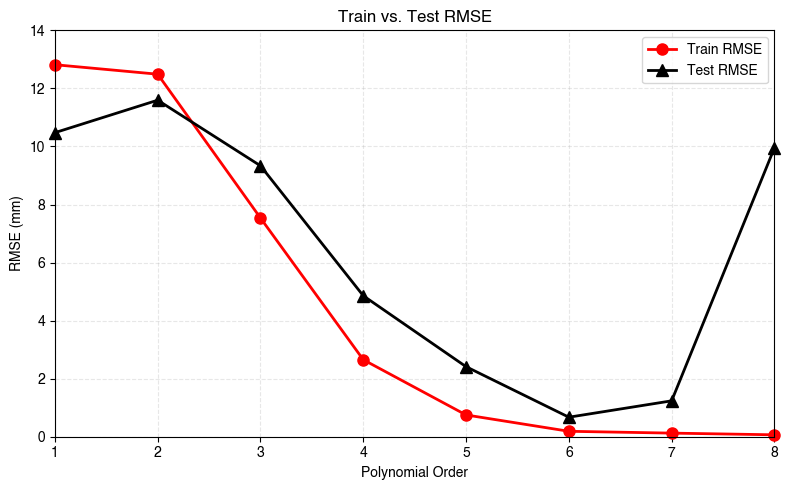

In [237]:
df = pd.read_csv('Untitled spreadsheet - Sheet1.csv')

plt.rcParams.update(plt.rcParamsDefault)

# 2. Setup the plot and styling
plt.rcParams['font.family'] = 'Helvetica'
fig, ax = plt.subplots(figsize=(8, 5))

plt.style.use('petroff10')

# 3. Plot Train RMSE (Red Circles, connected by a line)
# marker='o' gives us circles
ax.plot(df['Order'], df['Training RMSE'], marker='o', color='red',
        linestyle='-', linewidth=2, markersize=8, label='Train RMSE', clip_on=False)

# 4. Plot Test RMSE (Black Triangles, connected by a line)
# marker='^' gives us upward-pointing triangles
ax.plot(df['Order'], df['Test RMSE'], marker='^', color='black',
        linestyle='-', linewidth=2, markersize=8, label='Test RMSE', clip_on=False)

# 5. Format the X-Axis (Polynomial Order from 1 to 8)
ax.set_xlim(1, 8)
ax.set_xticks(range(1, 9))
ax.set_xlabel('Polynomial Order', fontweight='bold')

# 6. Format the Y-Axis (RMSE from 0 to 14, ticks every 2)
ax.set_ylim(0, 14)
# MultipleLocator(2) forces the ticks to appear exactly at 0, 2, 4, 6, 8, 10, 12, 14
ax.yaxis.set_major_locator(MultipleLocator(2))
ax.set_ylabel('RMSE (mm)', fontweight='bold')

# 7. Add Title, Legend, and Grid
ax.set_title('Train vs. Test RMSE', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)

# Save the plot
plt.tight_layout()
plt.savefig('RMSE_Comparison.png')

plt.show()